# LDM RL：从流程跑通，到证明有效学习

这批工作的进展，是把问题从“代码能否运行”推进到了“模型是否有效学习”。下一步应先验证可靠的参数更新，再用同预算的分子搜索结果判断 RL 是否优于 SFT。

In [1]:
from pathlib import Path
import json
from IPython.display import display
import matplotlib.pyplot as plt
from build_report import setup_font
from argument_figures import FIGURES
setup_font()
data = json.loads(Path("data/evidence.json").read_text())

## 2.1 运行结束不能作为训练成功的验收标准

在分子搜索强化学习中，程序完成、模型存档和有效优化是三件事。1.5B 的试跑已有有限梯度记录，但一条完成全部采样并保存模型的 9B 运行，100 次梯度记录全部是 NaN。我的判断是：流程已经能走完，训练成功的验收却必须增加参数更新与恢复验证，不能只看退出状态或文件是否存在。

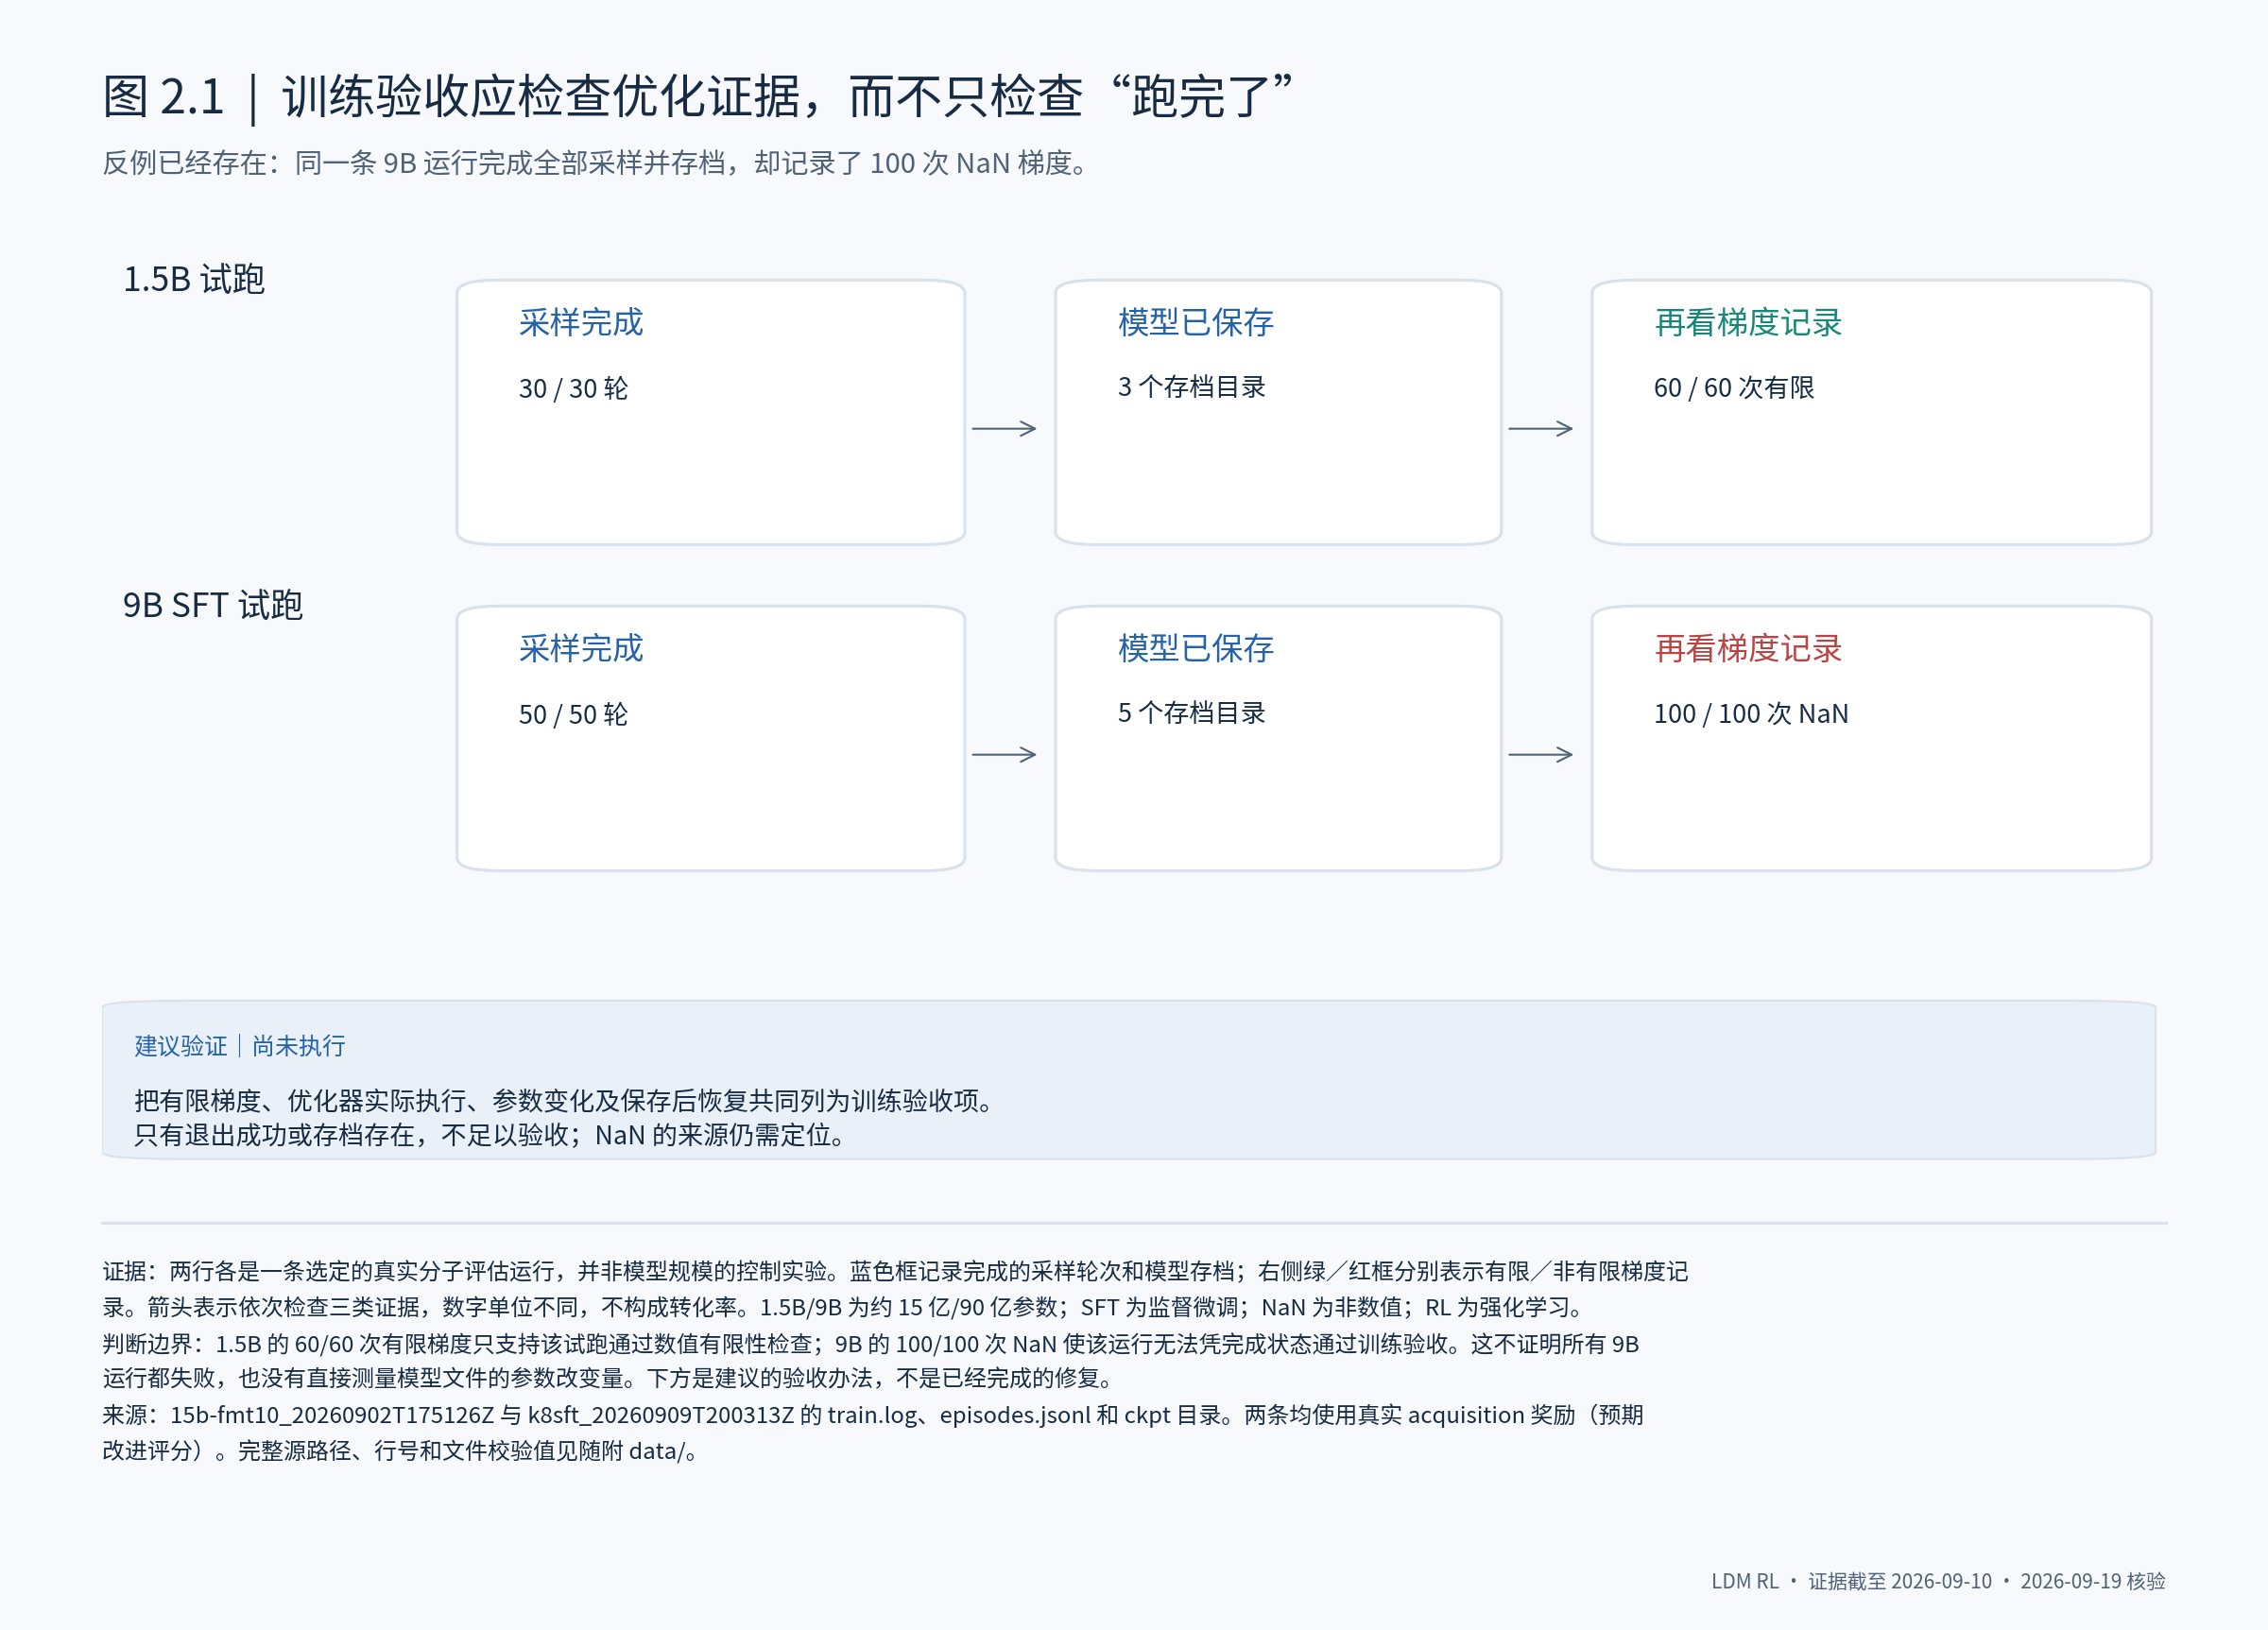

In [2]:
fig = FIGURES[0](data)
from io import BytesIO
from IPython.display import Image
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 2.2 消除 NaN 之后，还要验证参数是否被可靠地更新

9B 模型也出现过全程有限的梯度，但一条 SFT 运行的梯度范数从约 134 跨到 8.4×10¹¹。这个量级变化值得排查，却不足以单凭它断言训练失效。需要把裁剪前后梯度、优化器实际执行和参数改变量连起来核对；否则，“没有 NaN”仍然只是一个过于宽松的成功标准。

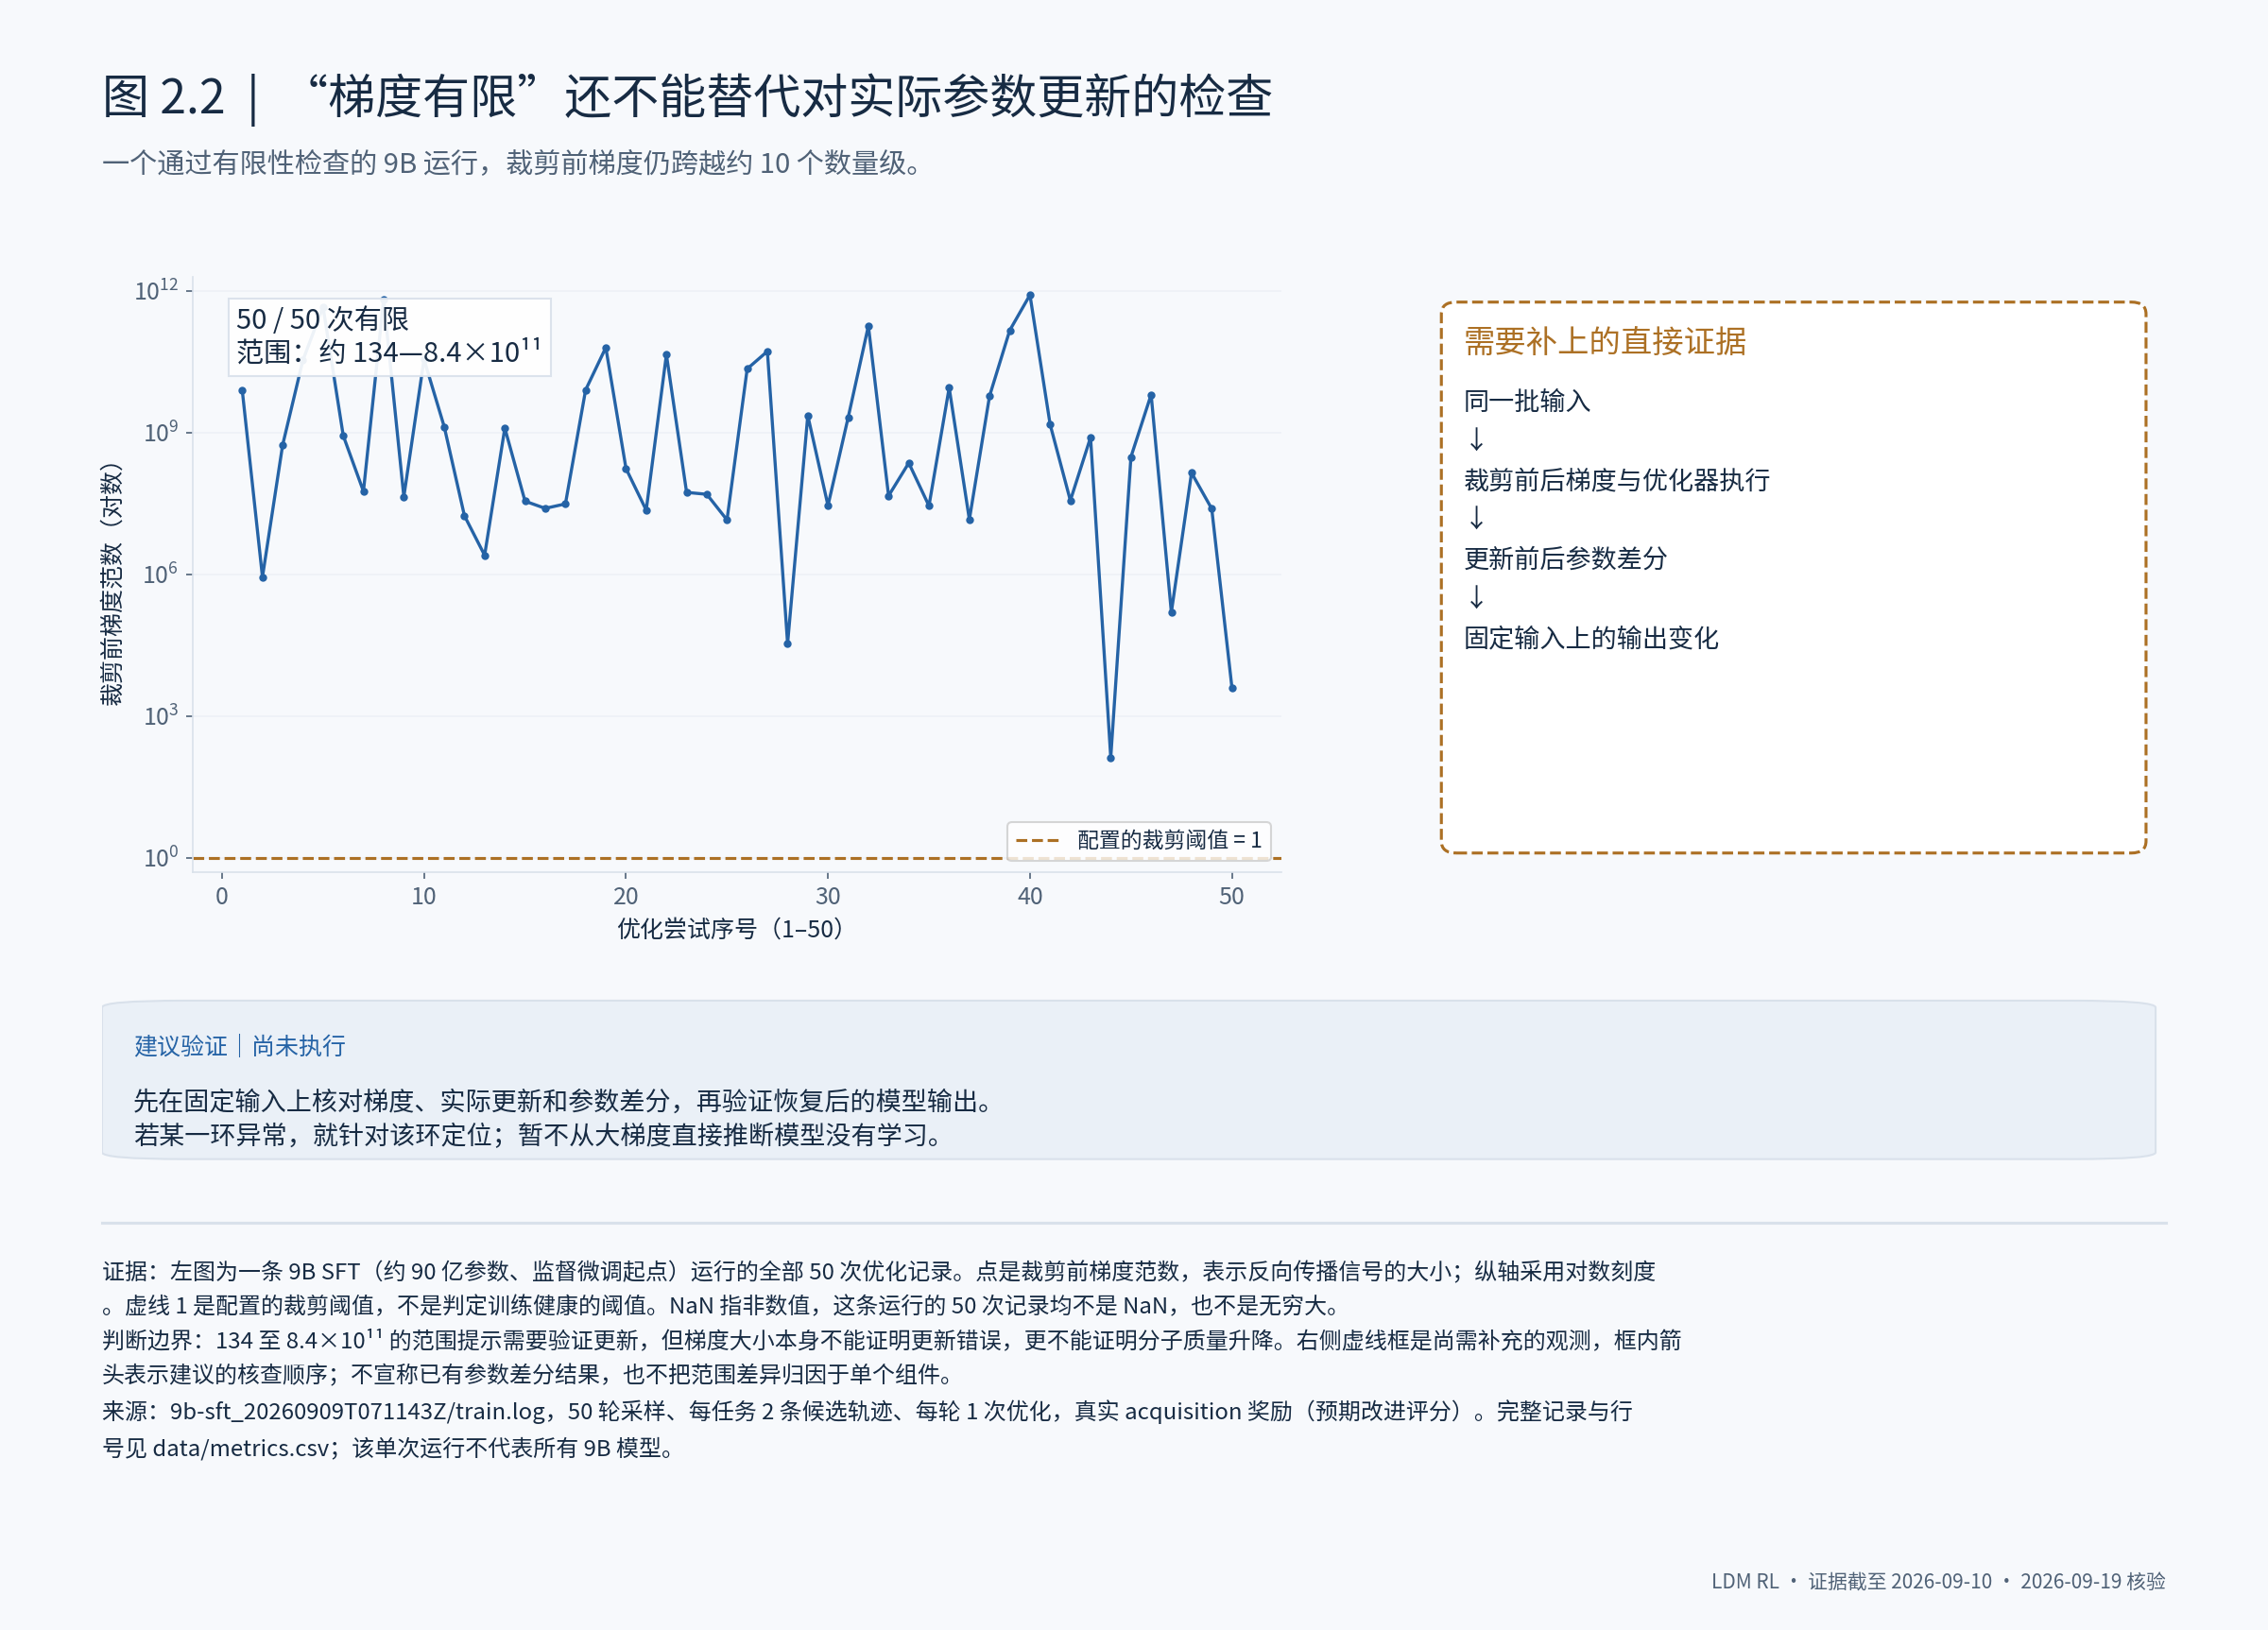

In [3]:
fig = FIGURES[1](data)
from io import BytesIO
from IPython.display import Image
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 2.3 奖励必须能区分候选，训练才有组内偏好可学

分子搜索的组相对优化，需要同一任务的候选轨迹拿到不同奖励。两条 9B SFT 运行中，全零奖励组分别占 49% 和 9%。这说明奖励无法区分候选是一个需要单独解决的问题；它还没有说明哪种配置最终更好。先把零奖励对应的候选、评估失败和无改进情况记录清楚，再决定扩大采样还是修改奖励。

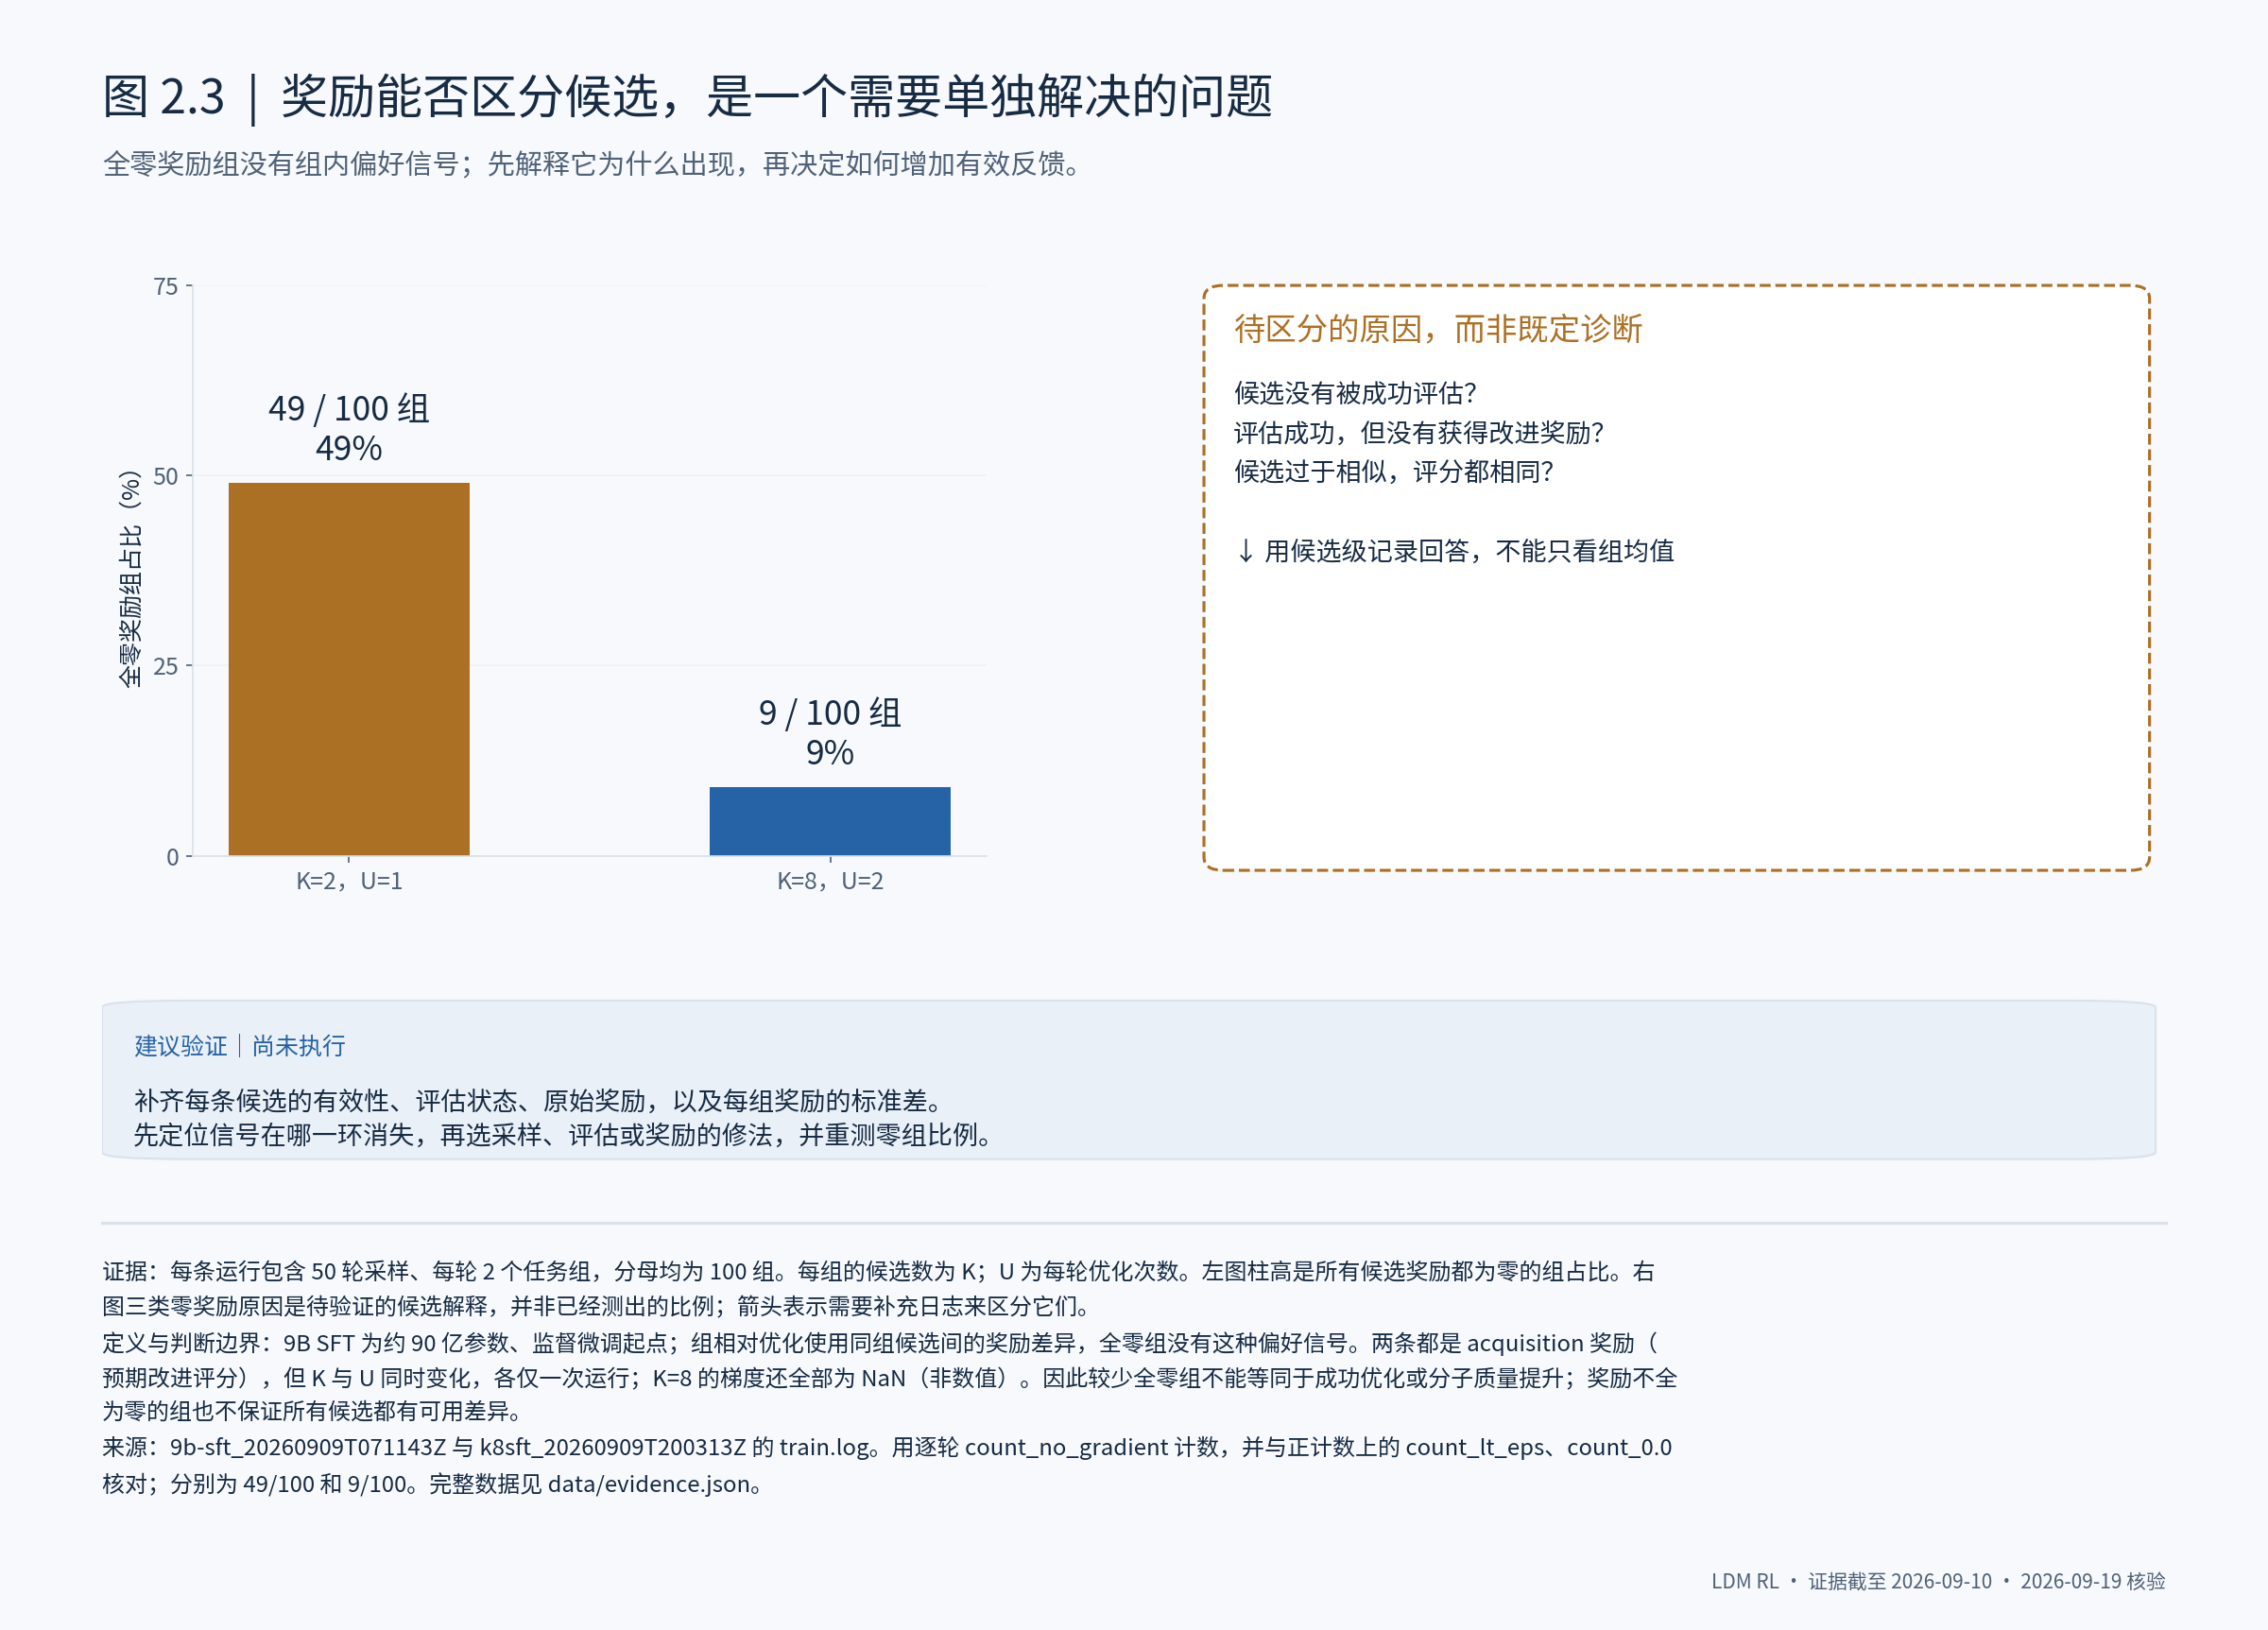

In [4]:
fig = FIGURES[2](data)
from io import BytesIO
from IPython.display import Image
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 2.4 要判断 K=8 的作用，必须拆开同时变化的训练条件

把每个任务的候选数从 2 改到 8 时，已有比较也把每轮更新次数从 1 改成了 2。而另一条候选数为 2、更新次数为 2 的运行只有 29 轮，不能直接补成等预算对照。我的判断是：49% 与 9% 是值得追查的线索，尚不足以推荐 K=8。冻结模型的奖励诊断与健康训练下的单因素对照，应分别回答奖励可区分性和学习收益。

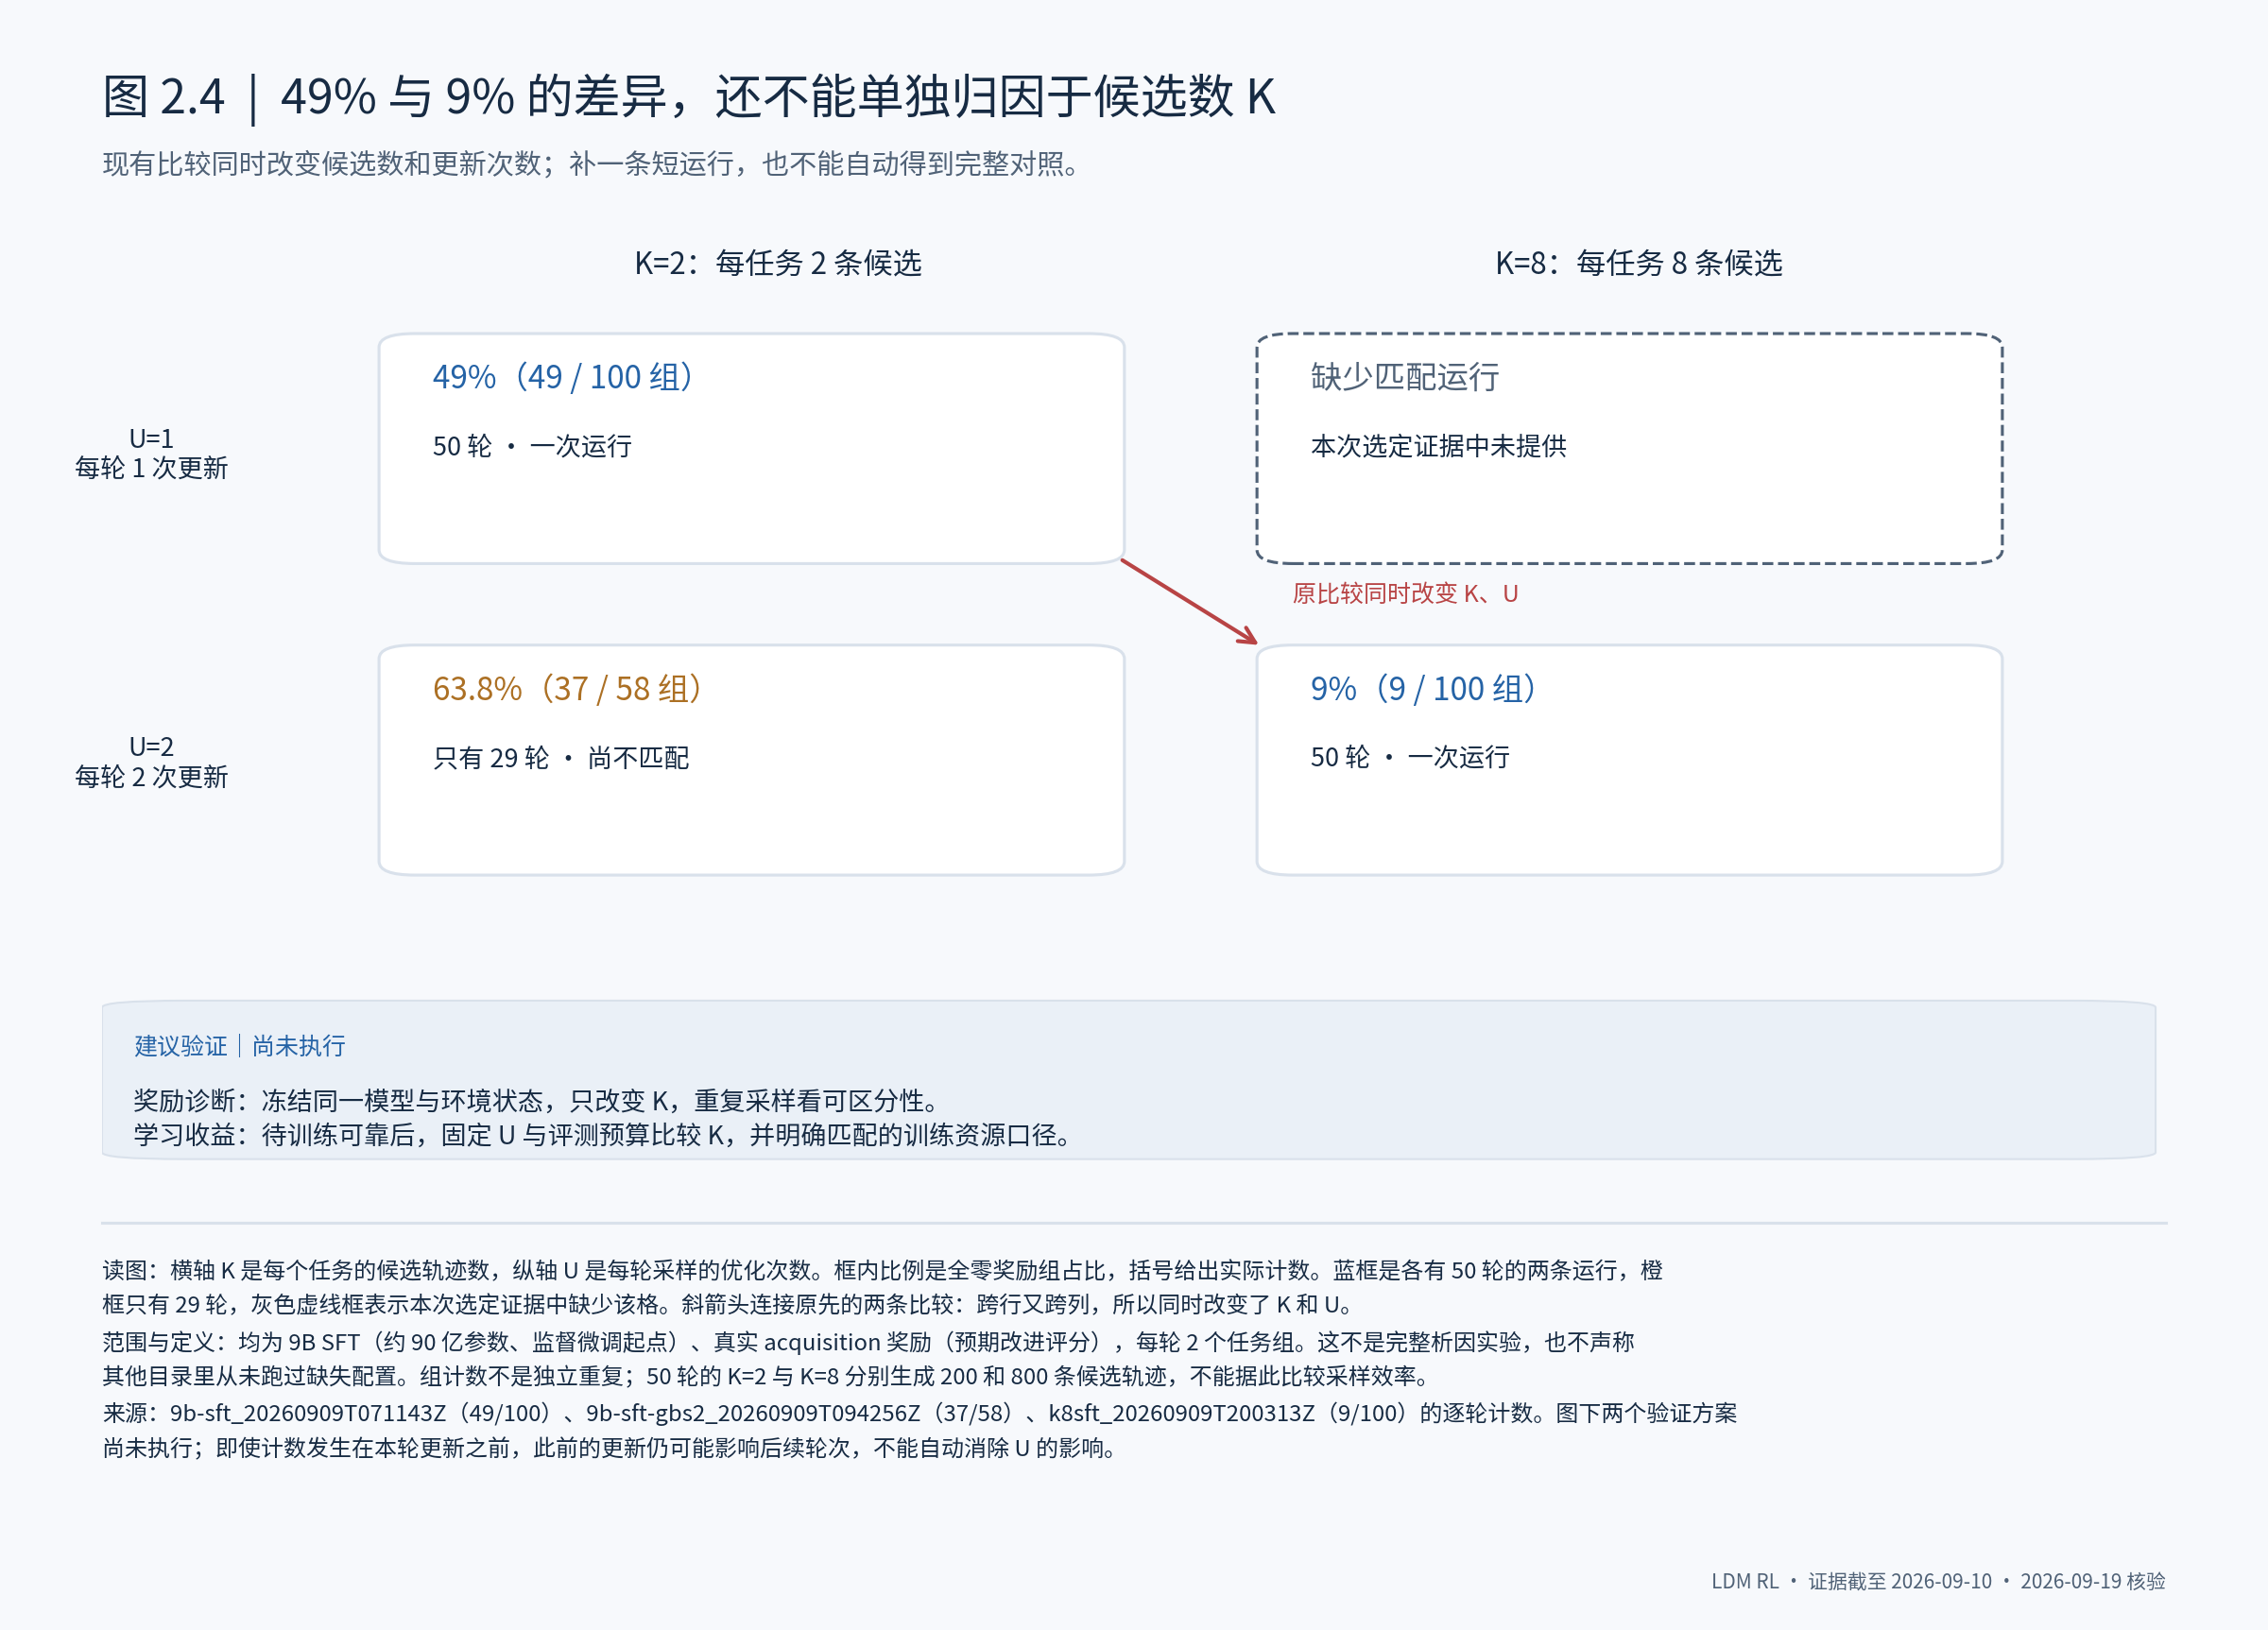

In [5]:
fig = FIGURES[3](data)
from io import BytesIO
from IPython.display import Image
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 2.5 RL 的收益必须由同预算的分子搜索成绩证明

这个项目最终要回答的是：在相同搜索预算下，继续强化学习的模型能否比仅监督微调的模型找到更好的分子。目前核查的材料还没有提供完整的 G12D/G12C 对照结果。因此，训练稳定性与奖励诊断都应服务于这张最终对照：固定评测协议、配对随机种子，比较 Pareto 超体积，而不把训练奖励当作效果结论。

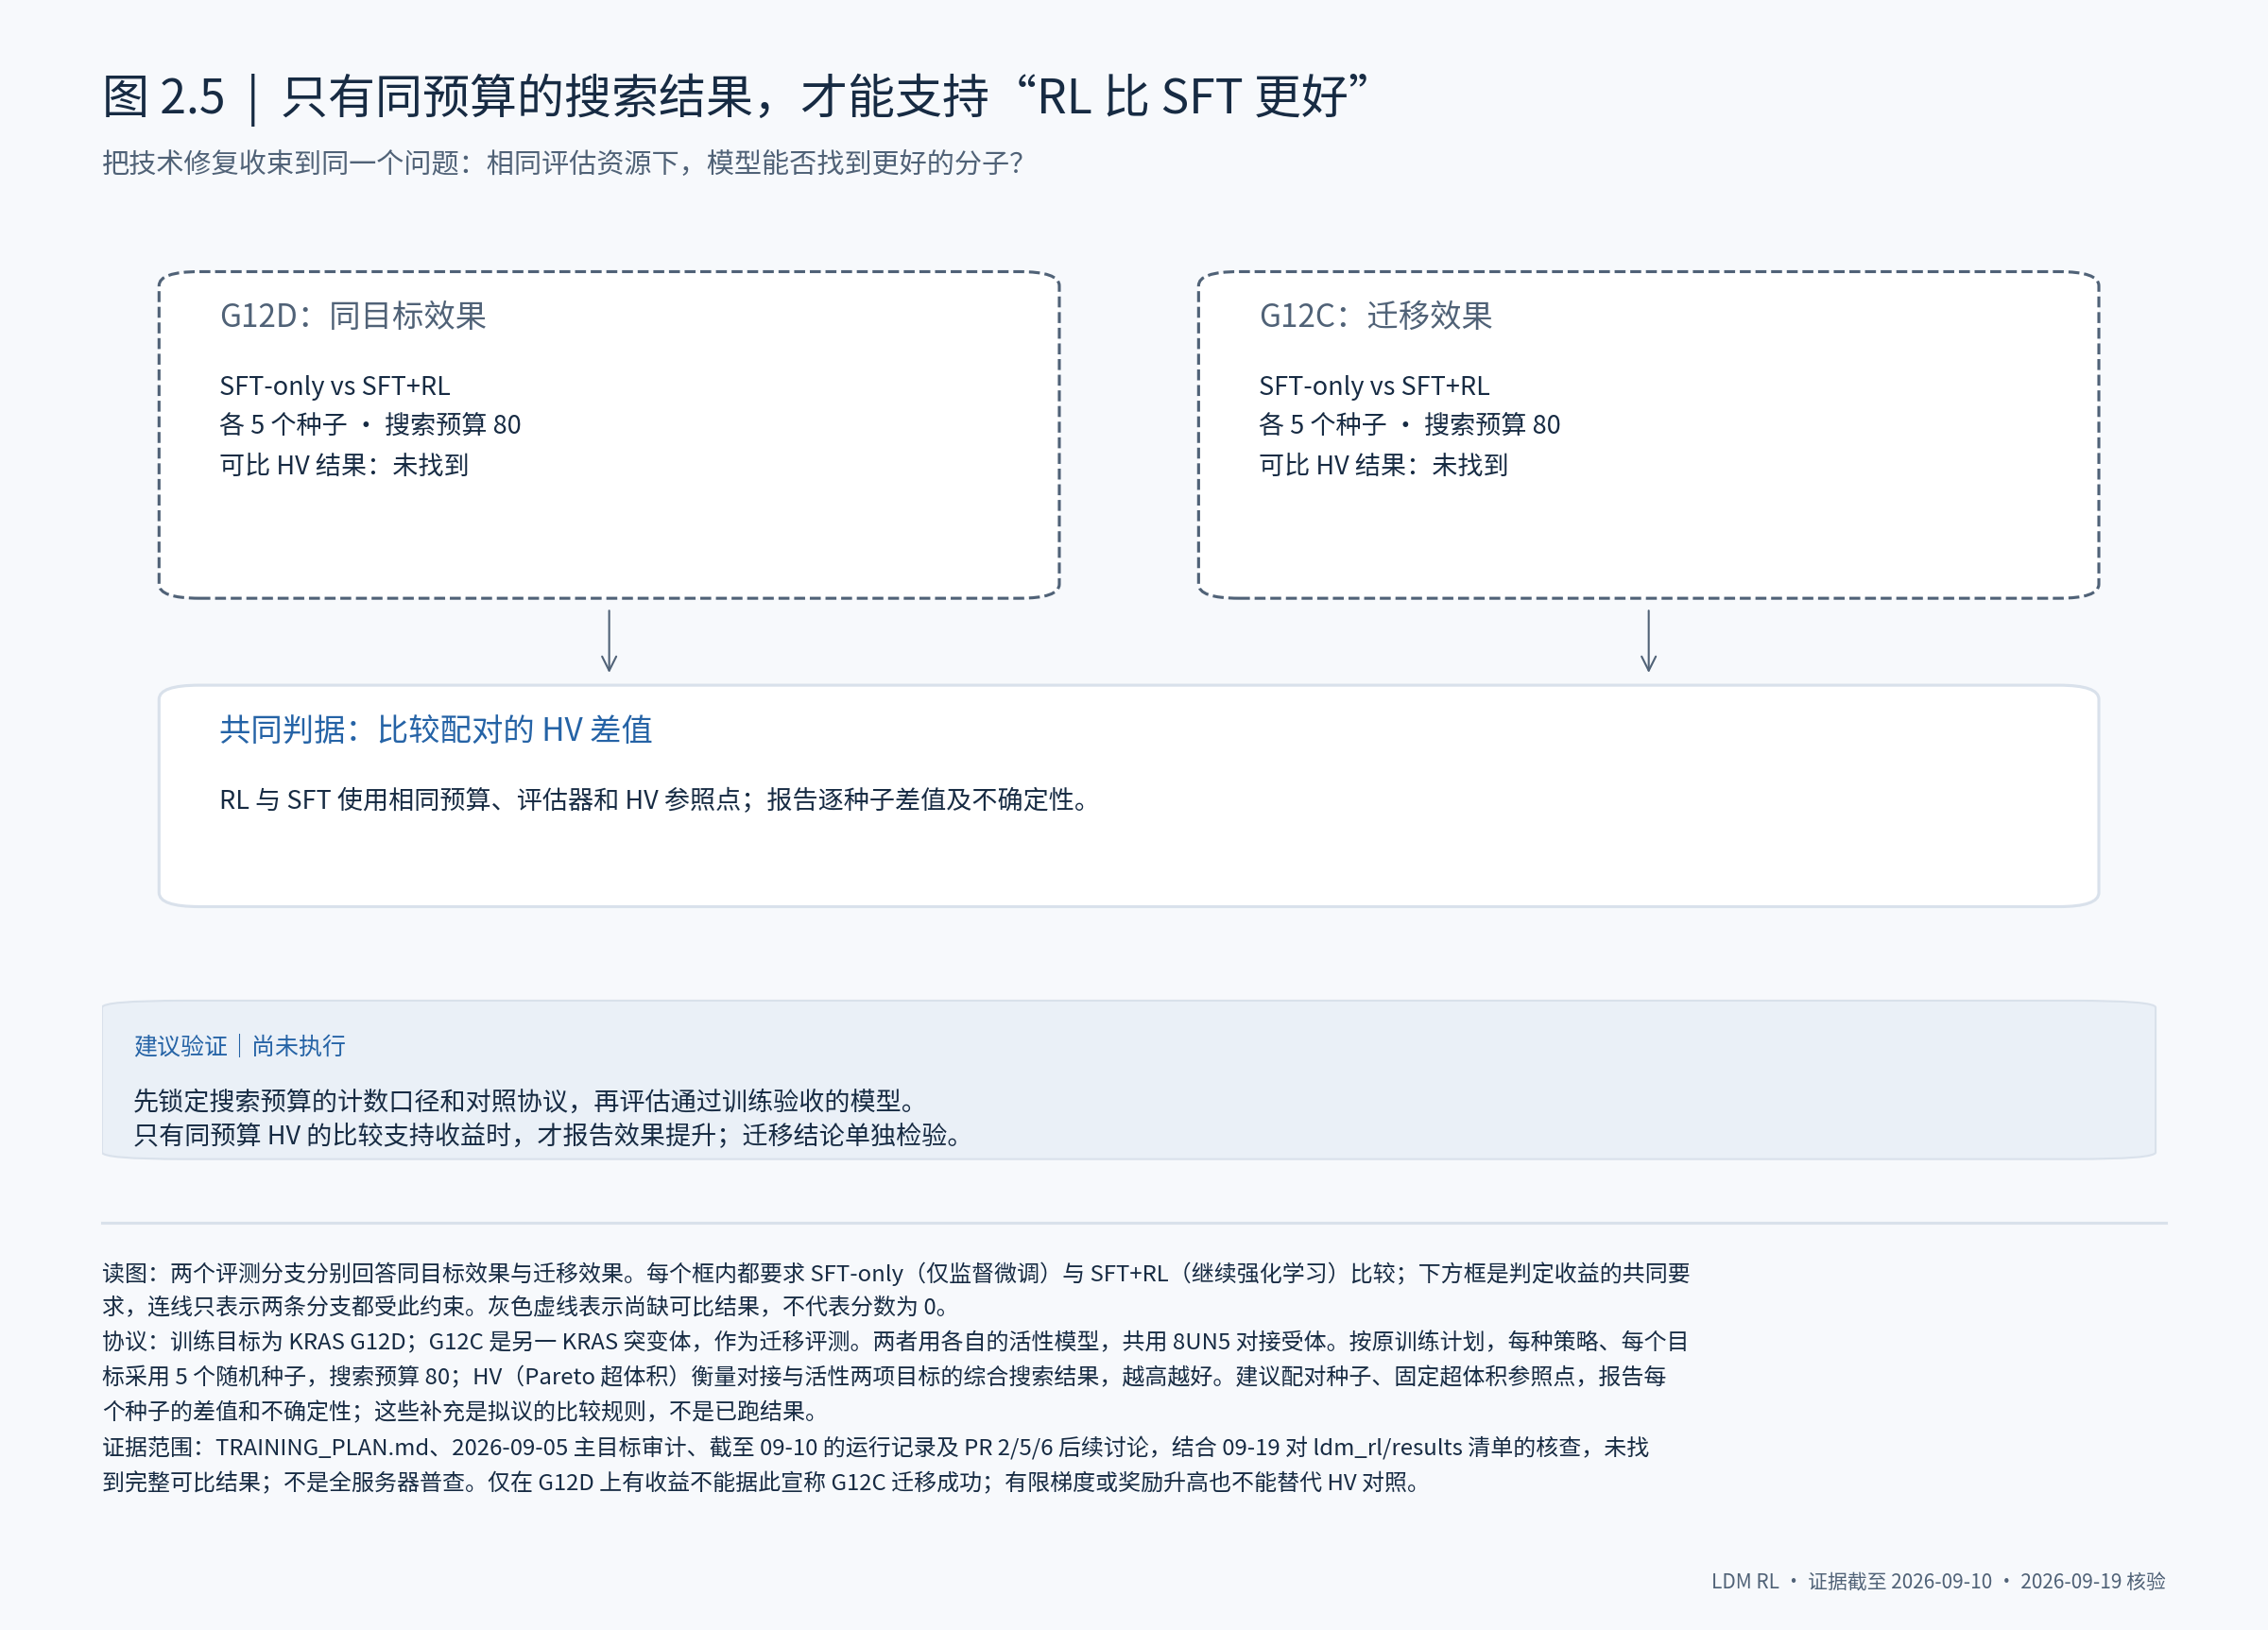

In [6]:
fig = FIGURES[4](data)
from io import BytesIO
from IPython.display import Image
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150)
display(Image(data=buf.getvalue()))
plt.close(fig)